In [1]:
import numpy as np
import open3d as o3d
from open3d.web_visualizer import draw

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[Open3D INFO] Resetting default logger to print to terminal.


In [5]:
import pickle
with open("/home/yan/IsaacLabDemo/assmble_imgs/test/models/cube_hole_random_template_8_in_points.pkl", "rb") as f:
    points = pickle.load(f)
print(type(points))

<class 'dict'>


In [6]:
print(points.keys())
print(type(points['/World/assembly_cube_hole_random_template_8_in_0/in_feature_247']))

dict_keys(['/World/assembly_cube_hole_random_template_8_in_0/in_feature_247', '/World/assembly_cube_hole_random_template_8_in_0/in_feature_509', '/World/assembly_cube_hole_random_template_8_in_0/CUBE_ASM_in', '/World/assembly_cube_hole_random_template_8_in_0/in_assembly_split_surface', '/World/assembly_cube_hole_random_template_8_in_0/in_feature_2551'])
<class 'numpy.ndarray'>


In [9]:
pc_dict_2_np = []
for k, v in points.items():
    if 'CUBE_ASM_in' in k:
        continue
    pc_dict_2_np.append(v)
pc_dict_2_np = np.concatenate(pc_dict_2_np)
print(pc_dict_2_np.shape)
o3d_anchor_pcs = o3d.geometry.PointCloud()
o3d_anchor_pcs.points = o3d.utility.Vector3dVector(pc_dict_2_np)
draw([o3d_anchor_pcs], title="Point Clouds", width=800, height=600)
## NOTE: 通过Isaac获取得到的点云是稀疏的，只保留少数顶点。

(724, 3)
[Open3D INFO] Window window_1 created.


WebVisualizer(window_uid='window_1')

In [2]:
from taxpose.datasets import CustomPretrainingPointCloudDatasetConfig, CustomPretrainingTotalPCDataset
dataset_embedding_config = CustomPretrainingPointCloudDatasetConfig(
    dataset_root="/home/yan/EmbodiedAgent/generate_data/pair_models/debug/test_data",
    num_points=4096,
    pc_aug=True,
    phase="test",
    dataset_type="total_pcs_pretraining"
)
dataset_embedding = CustomPretrainingTotalPCDataset(dataset_embedding_config)
print(len(dataset_embedding))

/home/yan/EmbodiedAgent/generate_data/pair_models/debug/test_data/cyl_asm_4_candi_0.npz
Total valid files: 76 / 76
Dataset length (raw): 76
Dataset length (final): 76
76


In [9]:
data = dataset_embedding[3]
print(type(data))
if isinstance(data, dict):
    print(data.keys())

<class 'dict'>
dict_keys(['part_pcs', 'n_pcs', 'data_id'])


In [3]:
# Concatenate points_anchor and points_action, and create a label vector for each point
import numpy as np
from rpad.visualize_3d.plots import pointcloud_fig
from rpad.visualize_3d.plots import segmentation_fig
data = dataset_embedding[6]
points = data["part_pcs"]
print(points.shape)
labels = np.zeros((points.shape[0])).astype(int)

segmentation_fig(
    points,
    labels,
)


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [18]:
pts = np.load("/home/yan/EmbodiedAgent/generate_data/pair_models/point_cloud/cube_asm_2_candi_2.npz")
print(pts.keys())
o3d_anchor_pcs = o3d.geometry.PointCloud()
o3d_anchor_pcs.points = o3d.utility.Vector3dVector(pts["anchor"])
o3d_anchor_pcs.paint_uniform_color([1, 0, 0])
o3d_base_pcs = o3d.geometry.PointCloud()
o3d_base_pcs.points = o3d.utility.Vector3dVector(pts["action"])
o3d_base_pcs.paint_uniform_color([0, 1, 0])
draw([o3d_anchor_pcs, o3d_base_pcs], title="Point Clouds", width=800, height=600)

KeysView(NpzFile '/home/yan/EmbodiedAgent/generate_data/pair_models/point_cloud/cube_asm_2_candi_2.npz' with keys: anchor, action, anchor_num, action_num)
[Open3D INFO] Window window_6 created.


WebVisualizer(window_uid='window_6')

In [7]:
! ls /home/yan/EmbodiedAgent/generate_data/pair_models/point_cloud

test_data  train_data


In [6]:
from taxpose.datasets import CustomPointCloudDataset, CustomPointCloudDatasetConfig
from rpad.visualize_3d.plots import pointcloud_fig
from rpad.visualize_3d.plots import segmentation_fig

dataset = CustomPointCloudDataset(
    CustomPointCloudDatasetConfig(
        dataset_root="/home/yan/EmbodiedAgent/generate_data/pair_models/debug/train_data",
        object_type="cube",
        action="place",
        action_class="place",
        anchor_class="cube",
        num_demo=1000,
        min_num_points=1024,
        max_num_cameras=1,
        min_num_cameras=1,
        cloud_type="pointcloud",
    )
)

77 / 77 demos left


In [9]:
print(len(dataset))
data = dataset[0] 
print(data["points_anchor"].shape)

651
(1, 1024, 3)


In [20]:
action, anchor = dataset.load_data(dataset.filenames[6], -1, -1)
print(action.shape, anchor.shape)

(1, 4000, 3) (1, 2000, 3)


In [ ]:
import open3d as o3d
import numpy as np
from rpad.visualize_3d.plots import segmentation_fig
pc1 = np.load('/home/yan/EmbodiedAgent/generate_data/point_cloud_completion/train/complete/cube_asm/014340331e49445bb414e7ede6f22b5e.npy')
pc2 = np.load('/home/yan/EmbodiedAgent/generate_data/point_cloud_completion/train/partial/cube_asm/014340331e49445bb414e7ede6f22b5e/00.npy',)
pc1 = pc1[None, :]
pc2 = pc2[None, :]
print(pc1.shape, pc2.shape)
print(np.isnan(pc1).max())
points_all = np.concatenate((pc1, pc2), axis=1)
labels = np.concatenate(
    (
        np.zeros((pc1.shape[1])),
        np.ones((pc2.shape[1])),
    ),
    axis=0,
).astype(int)
print(labels.shape)
segmentation_fig(
    points_all[0],
    labels,
)

FileNotFoundError: [Errno 2] No such file or directory: '/home/yan/EmbodiedAgent/generate_data/point_cloud_completion/train/complete/cube_asm/014340331e49445bb414e7ede6f22b5e.npy'

In [15]:
# Concatenate points_anchor and points_action, and create a label vector for each point
import numpy as np
from rpad.visualize_3d.plots import pointcloud_fig
from rpad.visualize_3d.plots import segmentation_fig
data = dataset[65]
points = data["points_anchor"]
points_action = data["points_action"]
print(points.shape, points_action.shape)
points_all = np.concatenate((points, points_action), axis=1)
labels = np.concatenate(
    (
        np.zeros((points.shape[1])),
        np.ones((points_action.shape[1])),
    ),
    axis=0,
).astype(int)
print(labels.shape)
segmentation_fig(
    points_all[0],
    labels,
)
# segmentation_fig(
#     points[0],
#     np.zeros((points.shape[1])).astype(int),
# )

(1, 1024, 3) (1, 1024, 3)
(2048,)


In [1]:
import torch
import torch.nn as nn
class SimpleRNN(nn.Module):
    """Simple RNN"""

    def __init__(self, inplace: bool = True) -> None:
        super().__init__()
        self.hid_dim = 2
        self.input_dim = 3
        self.max_length = 4
        self.lstm = nn.LSTMCell(self.input_dim, self.hid_dim)
        self.activation = nn.LeakyReLU(inplace=inplace)
        self.projection = nn.Linear(self.hid_dim, self.input_dim)

    def forward(self, token_embedding: torch.Tensor) -> torch.Tensor:
        b_size = token_embedding.size()[0]
        hx = torch.randn(b_size, self.hid_dim, device=token_embedding.device)
        cx = torch.randn(b_size, self.hid_dim, device=token_embedding.device)

        for _ in range(self.max_length):
            hx, cx = self.lstm(token_embedding, (hx, cx))
            hx = self.activation(hx)

        return hx

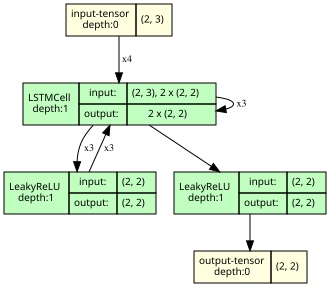

In [2]:
from torchview import draw_graph

model_graph = draw_graph(
    SimpleRNN(), input_size=(2, 3),
    graph_name='RecursiveNet',
    roll=True
)
model_graph.visual_graph


In [ ]:
from taxpose.nets.transformer_flow import create_network
import hydra
from torchview import draw_graph
import graphviz
graphviz.set_jupyter_format('png')
hydra.main(version_base="1.1", config_path="./configs", config_name="train_ndf")


In [5]:
import torch
from taxpose.nets.transformer_flow import ResidualFlow_DiffEmbTransformer
import hydra
from torchview import draw_graph
import graphviz
graphviz.set_jupyter_format('png')


class CFG:
    emb_dims = 512
    name = 'dgcnn'

def main(resume_ckpt):
    model = ResidualFlow_DiffEmbTransformer(
        encoder_cfg=CFG(),
        cycle=True,
        center_feature=True,
        pred_weight=True,
        residual_on=True,
        freeze_embnn=True,
        return_attn=True,
        multilaterate=False,
        mlat_sample=False,
        mlat_nkps=100,
        feature_channels=0,
        conditional=False,
        head_norm='LN',
        dropout=0.0,
    )
    checkpoint = torch.load(resume_ckpt, map_location='cpu')['state_dict']
    fix = 'model.'
    checkpoint = {k[len(fix):]: v for k, v in checkpoint.items() if k.startswith(fix)}
    model.load_state_dict(checkpoint)
    model.eval()
    # 创建一个虚拟输入
    dummy_input_1 = torch.randn(2, 1024, 3)
    dummy_input_2 = torch.randn(2, 1024, 3)
    # 4. 导出为 ONNX 格式
    # torch.onnx.export(model, (dummy_input_1, dummy_input_2), f"/home/yan/pose_estimation/taxpose/vis_taxpose.onnx")
    # print(f"ONNX model exported to {cfg.wandb.name}.onnx")
    model_graph = draw_graph(model,
                             input_data=(dummy_input_1, dummy_input_2),
                             device='cpu',
                             filename='test_graph',
                             save_graph=True)
    model_graph.visual_graph

main('/home/yan/pose_estimation/taxpose/logs/train_taxpose/2026-04-17/15-27-59/checkpoints/last.ckpt')

RuntimeError: Error(s) in loading state_dict for ResidualFlow_DiffEmbTransformer:
	Missing key(s) in state_dict: "head_action.proj_flow.convs.0.weight", "head_action.proj_flow.convs.1.weight", "head_action.proj_flow.convs.2.weight", "head_action.proj_flow.norms.0.weight", "head_action.proj_flow.norms.0.bias", "head_action.proj_flow.norms.1.weight", "head_action.proj_flow.norms.1.bias", "head_action.proj_flow.norms.2.weight", "head_action.proj_flow.norms.2.bias", "head_action.proj_flow.output.weight", "head_action.proj_flow_weight.convs.0.weight", "head_action.proj_flow_weight.convs.1.weight", "head_action.proj_flow_weight.convs.2.weight", "head_action.proj_flow_weight.convs.3.weight", "head_action.proj_flow_weight.convs.4.weight", "head_action.proj_flow_weight.norms.0.weight", "head_action.proj_flow_weight.norms.0.bias", "head_action.proj_flow_weight.norms.1.weight", "head_action.proj_flow_weight.norms.1.bias", "head_action.proj_flow_weight.norms.2.weight", "head_action.proj_flow_weigh

In [5]:
from taxpose.nets.transformer_flow import ResidualFlow_DiffEmbTransformer
import random
from taxpose.utils.se3 import random_se3
import torch
from torch import nn

class CFG:
    emb_dims = 512
    name = 'raw_dgcnn'
    knn = 16
    dropout = 0.3
    norm = 'BN'
    output_num = 512
    pos_encoding = False

resume_ckpt = '/home/yan/pose_estimation/taxpose/logs/train_taxpose/2026-05-14/18-40-56/checkpoints/last.ckpt'
# resume_ckpt = '/home/yan/pose_estimation/taxpose/logs/train_taxpose/2026-05-09/13-56-30/checkpoints/last.ckpt'
model = ResidualFlow_DiffEmbTransformer(
    encoder_cfg=CFG(),
    cycle=True,
    center_feature=True,
    pred_weight=True,
    residual_on=True,
    freeze_embnn=True,
    return_attn=True,
    multilaterate=False,
    mlat_sample=False,
    mlat_nkps=100,
    feature_channels=0,
    conditional=False,
    head_norm='LN',
    dropout=0.1,
    output_num=1024,
    pos_encoding=False,
    head_type="transformer"
)
checkpoint = torch.load(resume_ckpt, map_location='cpu')['state_dict']
fix = 'model.'
checkpoint = {k[len(fix):]: v for k, v in checkpoint.items() if k.startswith(fix)}
model.load_state_dict(checkpoint)
model.eval()
print(model)

ResidualFlow_DiffEmbTransformer(
  (emb_nn_action): DGCNN4TaxPose(
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv1): Sequential(
      (0): Conv2d(6, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
    (conv2): Sequential(
      (0): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
   

In [6]:
model.eval()
random_index = random.randint(0, len(dataset))
gt_action = torch.from_numpy(dataset[random_index]['points_action'])
gt_anchor = torch.from_numpy(dataset[random_index]['points_anchor'])
random_T0 = random_se3(1, device=gt_action.device)
random_T1 = random_se3(1, device=gt_anchor.device)
T1_cp = random_T0.inverse().compose(random_T1)
T2_cp = random_T1.compose(random_T0.inverse())

input_action = random_T0.transform_points(gt_action)
input_action = input_action - input_action.mean(dim=1, keepdim=True)
input_anchor = random_T1.transform_points(gt_anchor)
input_anchor = input_anchor - input_anchor.mean(dim=1, keepdim=True)
res_trans = model.forward(input_action, input_anchor, None, None)
scp = res_trans['corr_points_action']
scp_cented = scp - scp.mean(dim=1, keepdim=True)
scp_trans = random_T1.inverse().transform_points(scp)
scp_trans_cented = scp_trans - scp_trans.mean(dim=1, keepdim=True)
print(f"soft correspondence points: {scp.shape}")
emb_scp = model.emb_nn_action(scp_cented.permute(0, 2, 1))
print(f"emb_scp: {emb_scp.shape}")
emb_scp_trans = model.emb_nn_action(scp_trans_cented.permute(0, 2, 1))
sim = nn.functional.cosine_similarity(emb_scp[0, :, 0], emb_scp_trans[0, :, 0], dim=0)
print(f"similarity: {sim.shape}, {sim}")

soft correspondence points: torch.Size([1, 1024, 3])
emb_scp: torch.Size([1, 512, 1024])
similarity: torch.Size([]), 0.9999686479568481


In [18]:
Weg = nn.functional.softmax(torch.rand(1024, 1024), dim=-1)
w_scp = input_anchor.permute(0, 2, 1) @ Weg
w_scp = w_scp - w_scp.mean(dim=-1, keepdim=True)
emb_w_scp = model.emb_nn_action(w_scp)
anch_emb = model.emb_nn_anchor(input_anchor.permute(0, 2, 1)) @ Weg
sim = nn.functional.cosine_similarity(emb_scp, emb_scp_trans, dim=1)
print(f"similarity: {sim.shape}, {sim.mean()}")

similarity: torch.Size([1, 1024]), 0.9999282360076904


In [ ]:
with torch.no_grad():
    n_points = 1024
    scp_debug_emb = emb_scp.permute(2, 0, 1).repeat(1, n_points, 1)
    scp_trans_debug_emb = emb_scp_trans.permute(0, 2, 1).repeat(n_points, 1, 1)
    sim = nn.functional.cosine_similarity(scp_debug_emb[0:5, 0:10, :], scp_trans_debug_emb[0:5, 0:10, :], dim=-1)
    print(f"similarity: {sim}")
    print(f"scp_debug_emb: {scp_debug_emb.shape}")
    print(f"scp_debug_emb: {scp_trans_debug_emb.shape}")

scp_debug_emb: torch.Size([1024, 1024, 512])
scp_debug_emb: torch.Size([1024, 1024, 512])


In [ ]:
print(model.emb_nn_anchor.training)

False


In [5]:
model.eval()
random_index = random.randint(0, len(dataset))
gt_action = torch.from_numpy(dataset[random_index]['points_action'])
gt_anchor = torch.from_numpy(dataset[random_index]['points_anchor'])
random_T0 = random_se3(1, device=gt_action.device)
random_T1 = random_se3(1, device=gt_anchor.device)
T1_cp = random_T0.inverse().compose(random_T1)
T2_cp = random_T1.compose(random_T0.inverse())

input_action = random_T0.transform_points(gt_action)
input_anchor = random_T1.transform_points(gt_anchor)
res_trans = model.forward(input_action, input_anchor, None, None)
# random_gT0 = random_se3(1, device=gt_action.device)
# random_gT1 = random_se3(1, device=gt_anchor.device)
# random_T1 = random_T1.compose(random_gT0.inverse())
# gt_action = random_gT0.transform_points(gt_action)
# gt_anchor = random_gT1.transform_points(gt_anchor)
res_gt = model.forward(gt_action, gt_anchor, None, None)

input_action_center = input_action - input_action.mean(dim=1, keepdim=True)
input_anchor_center = input_anchor - input_anchor.mean(dim=1, keepdim=True)

delta = random_T1.transform_points(gt_action) - T1_cp.transform_points(input_action)
print(f"{delta.mean()}")

print(f"res trans: {res_trans['corr_points_action'].shape}, {res_trans['corr_points_anchor'].shape}")
print(f"res gt: {res_gt['corr_points_action'].shape}, {res_gt['corr_points_anchor'].shape}")
delta_W = res_trans['attns'] - res_gt['attns']
print(f"delta W: {delta_W.shape}, mean: {delta_W.mean()}, std: {delta_W.std()}, min: {delta_W.min()}, max: {delta_W.max()}")
## residual flow is of SE(3)-equivariant
delta_B = res_trans['residual_flow_action'] - res_gt['residual_flow_action']
print(f"delta B: {delta_B.shape}, mean: {delta_B.mean()}, std: {delta_B.std()}, min: {delta_B.min()}, max: {delta_B.max()}")
## soft correspondence points are of SE(3)-equivariant
pab_R = res_trans['attns'] @ input_anchor
pab_gt = res_gt['attns'] @ gt_anchor
print(f"rel corr_pts mean: {torch.norm(pab_R-random_T1.transform_points(pab_gt), p=1,dim=-1).mean()}")
delta_soft_cps = torch.norm(res_trans['corr_points_action'] - res_gt['corr_points_action'], p=1, dim=-1)
print(f"soft cps comp for pre: {delta_soft_cps.shape}, mean: {delta_soft_cps.mean()}, std: {delta_soft_cps.std()}, min: {delta_soft_cps.min()}, max: {delta_soft_cps.max()}")
delta_soft_cps = torch.norm((res_trans['corr_points_action'] - random_T1.transform_points(res_gt['corr_points_action'])),p=1,dim=-1)
print(f"soft cps comp for gt: {delta_soft_cps.shape}, mean: {delta_soft_cps.mean()}, std: {delta_soft_cps.std()}, min: {delta_soft_cps.min()}, max: {delta_soft_cps.max()}")

# residual flow is not of SE(3)-equivariant
print(f"res norm: {torch.norm(res_trans['residual_flow_action'], p=2, dim=-1).mean()}")
delta_res_flow = torch.norm(res_trans['residual_flow_action'] - res_gt['residual_flow_action'], p=1, dim=-1)
print(f"delta res flow: {delta_res_flow.shape}, mean: {delta_res_flow.mean()}, std: {delta_res_flow.std()}, min: {delta_res_flow.min()}, max: {delta_res_flow.max()}")
delta_res_flow = torch.norm(res_trans['residual_flow_action'] - res_gt['residual_flow_action'] @ random_T1.get_matrix()[0,:3,:3], p=1, dim=-1)
print(f"delta res flow: {delta_res_flow.shape}, mean: {delta_res_flow.mean()}, std: {delta_res_flow.std()}, min: {delta_res_flow.min()}, max: {delta_res_flow.max()}")

# random_coarse = torch.rand_like(res_gt['corr_points'])
rel_res_flow = random_T1.transform_points(gt_action) - res_trans['corr_points_action']
base_res_flow = gt_action - res_gt['corr_points_action']
delta_res_flow = torch.norm(rel_res_flow - base_res_flow, p=2, dim=-1)
print(f"delta res flow: {delta_res_flow.shape}, mean: {delta_res_flow.mean()}, std: {delta_res_flow.std()}, min: {delta_res_flow.min()}, max: {delta_res_flow.max()}")
delta_res_flow = torch.norm(rel_res_flow - base_res_flow @ random_T1.get_matrix()[0,:3,:3], p=2, dim=-1)
print(f"delta res flow: {delta_res_flow.shape}, mean: {delta_res_flow.mean()}, std: {delta_res_flow.std()}, min: {delta_res_flow.min()}, max: {delta_res_flow.max()}")



-6.322504186861977e-10
res trans: torch.Size([1, 1024, 3]), torch.Size([1, 1024, 3])
res gt: torch.Size([1, 1024, 3]), torch.Size([1, 1024, 3])
delta W: torch.Size([1, 1024, 1024]), mean: 1.1906031716080179e-12, std: 0.00014518773241434246, min: -0.016791071742773056, max: 0.012590158730745316
delta B: torch.Size([1, 1024, 3]), mean: 5.583521911489697e-08, std: 1.3213760212238412e-05, min: -2.3530792532255873e-05, max: 4.411206464283168e-05
rel corr_pts mean: 0.0011940514668822289
soft cps comp for pre: torch.Size([1, 1024]), mean: 0.07721105217933655, std: 0.0012385477311909199, min: 0.06987786293029785, max: 0.081364706158638
soft cps comp for gt: torch.Size([1, 1024]), mean: 0.0011940514668822289, std: 0.00098896655254066, min: 6.937095895409584e-05, max: 0.00907846912741661
res norm: 6.98491494404152e-05
delta res flow: torch.Size([1, 1024]), mean: 3.4456421417417005e-05, std: 4.358826572570251e-06, min: 2.3659071302972734e-05, max: 6.30143767921254e-05
delta res flow: torch.Size([

In [6]:
print(torch.norm(res_trans['residual_flow_action'], dim=-1))

tensor([[2.8035e-05, 7.2364e-05, 1.4440e-04,  ..., 5.1294e-05, 6.1525e-05,
         1.1682e-04]], grad_fn=<LinalgVectorNormBackward0>)


In [7]:
from taxpose.utils.se3 import dualflow2pose, get_degree_angle, get_translation
from pytorch3d.transforms import Rotate
from pytorch3d.ops import iterative_closest_point

act_flow, act_weight = res_trans['flow_action'][:, :, :3], res_trans['flow_action'][:, :, 3]
anchor_flow, anchor_weight = res_trans['flow_anchor'][:, :, :3], res_trans['flow_anchor'][:, :, 3]

pred_T_action = dualflow2pose(
    input_action,
    input_anchor,
    act_flow,
    anchor_flow,
    weights_src=None,
    weights_tgt=None,
    return_transform3d=False,
    normalization_scehme="l1",
    temperature=1,
    training=True
)
initR, initT = pred_T_action
pred_T_action = Rotate(initR).translate(initT)
print(get_degree_angle(T1_cp.compose(pred_T_action.inverse()))[-1])
print(get_translation(T1_cp.compose(pred_T_action.inverse()))[-1])

ICP_action = dualflow2pose(
    input_action,
    input_anchor,
    act_flow,
    anchor_flow,
    weights_src=None,
    weights_tgt=None,
    return_transform3d=True,
    normalization_scehme="l1",
    temperature=1,
    training=model.training,
    max_iter=100
)

print(get_degree_angle(T1_cp.compose(ICP_action.inverse()))[-1])
print(get_translation(T1_cp.compose(ICP_action.inverse()))[-1])

icp_res = iterative_closest_point(
    input_action, input_anchor
)
pose = Rotate(icp_res.RTs.R).translate(icp_res.RTs.T)
print(f"ICP result: {icp_res.rmse}, ite count: {len(icp_res.t_history)}, converged: {icp_res.converged}")
print(get_degree_angle(T1_cp.compose(pose.inverse()))[-1])
print(get_translation(T1_cp.compose(pose.inverse()))[-1])

print(initR.shape)
icp_res = iterative_closest_point(
    input_action, input_anchor, init_transform=(initR, initT, torch.ones_like(initT)[:, 0])
)
pose = Rotate(icp_res.RTs.R).translate(icp_res.RTs.T)
print(f"ICP result: {icp_res.rmse}, ite count: {len(icp_res.t_history)}, converged: {icp_res.converged}")
print(get_degree_angle(T1_cp.compose(pose.inverse()))[-1])
print(get_translation(T1_cp.compose(pose.inverse()))[-1])

52.01837921142578
0.031094292178750038
ICP result: tensor([0.0127]), ite count: 28, converged: True
4.022727012634277
0.012155270203948021
ICP result: tensor([0.0127]), ite count: 45, converged: True
4.0081939697265625
0.012153799645602703
torch.Size([1, 3, 3])
ICP result: tensor([0.0127]), ite count: 28, converged: True
4.022727012634277
0.012155270203948021


In [29]:
print(T1_cp.get_matrix())
print(random_T0.get_matrix())
print(random_T1.get_matrix())


tensor([[[ 0.9984, -0.0458, -0.0332,  0.0000],
         [ 0.0475,  0.9975,  0.0521,  0.0000],
         [ 0.0307, -0.0536,  0.9981,  0.0000],
         [ 0.0170,  0.0395, -0.0649,  1.0000]]])
tensor([[[ 0.9976,  0.0683,  0.0148,  0.0000],
         [-0.0680,  0.9975, -0.0193,  0.0000],
         [-0.0161,  0.0183,  0.9997,  0.0000],
         [ 0.0274, -0.0484,  0.0422,  1.0000]]])
tensor([[[ 0.9997,  0.0216, -0.0147,  0.0000],
         [-0.0211,  0.9992,  0.0349,  0.0000],
         [ 0.0155, -0.0346,  0.9993,  0.0000],
         [ 0.0433, -0.0123, -0.0262,  1.0000]]])


In [7]:
data = dataset[random_index]
print(gt_action.shape, gt_anchor.shape)
points_all = np.concatenate((input_action, random_T1.transform_points(gt_action), input_anchor), axis=1)
labels = np.concatenate(
    (
        np.zeros((input_action.shape[1])),
        np.ones((gt_action.shape[1])),
        np.ones((gt_anchor.shape[1])) * 2,
    ),
    axis=0,
).astype(int)
print(labels.shape)
segmentation_fig(
    points_all[0],
    labels,
)

torch.Size([1, 1024, 3]) torch.Size([1, 1024, 3])
(3072,)


In [ ]:
print(f"res trans: {res_trans['corr_points_action'].shape}, {res_trans['corr_points_anchor'].shape}")
print(f"res gt: {res_gt['corr_points_action'].shape}, {res_gt['corr_points_anchor'].shape}")
delta_W = res_trans['attns'] - res_gt['attns']
print(f"delta W: {delta_W.shape}, mean: {delta_W.mean()}, std: {delta_W.std()}, min: {delta_W.min()}, max: {delta_W.max()}")

## soft correspondence points are of SE(3)-equivariant
delta_soft_cps = torch.norm(res_trans['corr_points'] - res_gt['corr_points'], p=1, dim=-1)
print(f"soft cps comp for pre: {delta_soft_cps.shape}, mean: {delta_soft_cps.mean()}, std: {delta_soft_cps.std()}, min: {delta_soft_cps.min()}, max: {delta_soft_cps.max()}")
delta_soft_cps = torch.norm((res_trans['corr_points'] - random_T1.transform_points(res_gt['corr_points'])),p=1,dim=-1)
print(f"soft cps comp for gt: {delta_soft_cps.shape}, mean: {delta_soft_cps.mean()}, std: {delta_soft_cps.std()}, min: {delta_soft_cps.min()}, max: {delta_soft_cps.max()}")

# residual flow is not of SE(3)-equivariant
delta_res_flow = torch.norm(res_trans['residual_flow_action'] - res_gt['residual_flow_action'], p=1, dim=-1)
print(f"delta res flow: {delta_res_flow.shape}, mean: {delta_res_flow.mean()}, std: {delta_res_flow.std()}, min: {delta_res_flow.min()}, max: {delta_res_flow.max()}")
delta_res_flow = torch.norm(res_trans['residual_flow_action'] - res_gt['residual_flow_action'] @ random_T1.get_matrix()[0,:3,:3], p=1, dim=-1)
print(f"delta res flow: {delta_res_flow.shape}, mean: {delta_res_flow.mean()}, std: {delta_res_flow.std()}, min: {delta_res_flow.min()}, max: {delta_res_flow.max()}")

# random_coarse = torch.rand_like(res_gt['corr_points'])
rel_res_flow = random_T1.transform_points(gt_action) - res_trans['corr_points']
base_res_flow = random_gT1.transform_points(gt_action) - res_gt['corr_points']
delta_res_flow = torch.norm(rel_res_flow - base_res_flow, p=2, dim=-1)
print(f"delta res flow: {delta_res_flow.shape}, mean: {delta_res_flow.mean()}, std: {delta_res_flow.std()}, min: {delta_res_flow.min()}, max: {delta_res_flow.max()}")
delta_res_flow = torch.norm(rel_res_flow - base_res_flow @ random_T1.get_matrix()[0,:3,:3], p=2, dim=-1)
print(f"delta res flow: {delta_res_flow.shape}, mean: {delta_res_flow.mean()}, std: {delta_res_flow.std()}, min: {delta_res_flow.min()}, max: {delta_res_flow.max()}")

res trans: torch.Size([1, 1024, 3]), torch.Size([1, 1024, 3])
res gt: torch.Size([1, 1024, 3]), torch.Size([1, 1024, 3])
delta W: torch.Size([1, 1024, 1024]), mean: -6.181721801112872e-13, std: 0.002325319917872548, min: -0.21727457642555237, max: 0.3042329251766205
soft cps comp for pre: torch.Size([1, 1024]), mean: 0.059139497578144073, std: 0.009745243936777115, min: 0.031259745359420776, max: 0.12857846915721893
soft cps comp for gt: torch.Size([1, 1024]), mean: 0.06130193546414375, std: 0.0072060879319906235, min: 0.03405770659446716, max: 0.11884507536888123


In [84]:
from taxpose.nets.gemo_fea import ManualPointWiseGemoFea
ppf_fea = ManualPointWiseGemoFea(False, 256, 1024)
fea_base = ppf_fea(gt_anchor)
fea_R = ppf_fea(input_anchor)
delta = fea_base - fea_R
print(f"delta.mean: {delta.mean()}, shape: {delta.shape}")

delta.mean: 0.00245215673930943, shape: torch.Size([1, 24, 1024])


In [9]:
print(res_trans['residual_flow_action'].mean())
print(res_gt['residual_flow_action'].mean())

tensor(0.0021, grad_fn=<MeanBackward0>)
tensor(0.0020, grad_fn=<MeanBackward0>)


In [10]:
# residual flow is not of SE(3)-equivariant
delta_res_flow = torch.norm(res_trans['residual_flow_action'] - res_gt['residual_flow_action'], p=1, dim=-1)
print(f"delta res flow: {delta_res_flow.shape}, mean: {delta_res_flow.mean()}, std: {delta_res_flow.std()}, min: {delta_res_flow.min()}, max: {delta_res_flow.max()}")
delta_res_flow = torch.norm(res_trans['residual_flow_action'] - res_gt['residual_flow_action'] @ random_T1.get_matrix()[0,:3,:3], p=1, dim=-1)
print(f"delta res flow: {delta_res_flow.shape}, mean: {delta_res_flow.mean()}, std: {delta_res_flow.std()}, min: {delta_res_flow.min()}, max: {delta_res_flow.max()}")

# random_coarse = torch.rand_like(res_gt['corr_points'])
rel_res_flow = random_T1.transform_points(gt_action) - res_trans['corr_points']
base_res_flow = random_gT1.transform_points(gt_action) - res_gt['corr_points']
delta_res_flow = torch.norm(rel_res_flow - base_res_flow, p=2, dim=-1)
print(f"delta res flow: {delta_res_flow.shape}, mean: {delta_res_flow.mean()}, std: {delta_res_flow.std()}, min: {delta_res_flow.min()}, max: {delta_res_flow.max()}")
delta_res_flow = torch.norm(rel_res_flow - base_res_flow @ random_T1.get_matrix()[0,:3,:3], p=2, dim=-1)
print(f"delta res flow: {delta_res_flow.shape}, mean: {delta_res_flow.mean()}, std: {delta_res_flow.std()}, min: {delta_res_flow.min()}, max: {delta_res_flow.max()}")

delta res flow: torch.Size([1, 1024]), mean: 0.0007136616040952504, std: 0.0006055811536498368, min: 9.384555596625432e-06, max: 0.004036754369735718
delta res flow: torch.Size([1, 1024]), mean: 0.0008216675487346947, std: 0.0006067543290555477, min: 5.3748979553347453e-05, max: 0.004095740150660276
delta res flow: torch.Size([1, 1024]), mean: 0.02571636065840721, std: 0.008085700683295727, min: 0.005099890287965536, max: 0.08049158751964569
delta res flow: torch.Size([1, 1024]), mean: 0.025356939062476158, std: 0.0066568003967404366, min: 0.007137494161725044, max: 0.07369498908519745


In [138]:
(base_res_flow @ random_T1.get_matrix()[0, :3,:3]).shape

torch.Size([1, 1024, 3])

In [127]:
random_coarse = torch.rand_like(res_gt['corr_points'])
res1 = random_T1.transform_points(gt_action) - random_T1.transform_points(random_coarse)
res2 = random_T1.transform_points(gt_action - random_coarse)
print(torch.norm(res1 - res2, dim=-1).mean())

tensor(0.0985)


In [75]:
delta = base_res_flow - res_gt['residual_flow_action']
print('Delta:', delta.mean(), delta.std())

Delta: tensor(-0.0016, grad_fn=<MeanBackward0>) tensor(0.0472, grad_fn=<StdBackward0>)


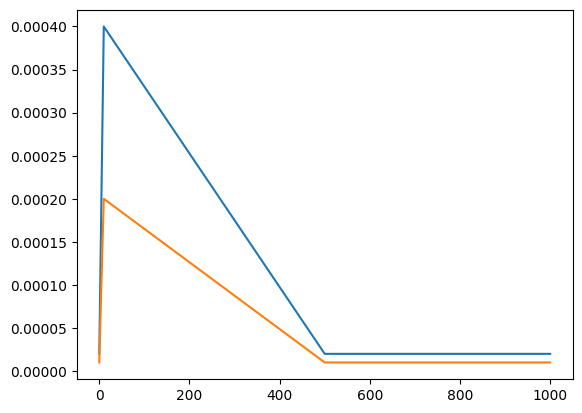

In [22]:
import matplotlib.pyplot as plt
import numpy as np
max_lr = 4e-4
min_lr = 2e-5
warm_steps = 10
max_steps = 1000
x = np.linspace(0, max_steps, 1000)
y1 = (max_lr - min_lr) * (500-x)/(500-warm_steps) + min_lr
y1[x<warm_steps] = (max_lr - min_lr) * x[x<warm_steps]/warm_steps + min_lr
y1[x>500] = min_lr

max_lr = 2e-4
min_lr = 1e-5
warm_steps = 10
max_steps = 1000
x = np.linspace(0, max_steps, 1000)
y2 = (max_lr - min_lr) * (500-x)/(500-warm_steps) + min_lr
y2[x<warm_steps] = (max_lr - min_lr) * x[x<warm_steps]/warm_steps + min_lr
y2[x>500] = min_lr

plt.plot(x, [y1[i] for i in range(len(x))], label="DGCNN")
plt.plot(x, [y2[i] for i in range(len(x))], label="RawDGCNN")
plt.show()

In [ ]:
import torch
def compute_res_smoothness_loss(pred_res_flow, points_trans_action, k=16):
    delta = pred_res_flow
    b, n, c = pred_res_flow.shape
    pair_dis = torch.cdist(points_trans_action, points_trans_action)
    top_k_idx = pair_dis.topk(k, largest=False)[1]
    batch_offset = torch.arange(b).view(b, 1, 1) * n
    idx = top_k_idx + batch_offset                             # (B, M, k)
    idx_flat = idx.reshape(-1, k)
    gathered_feat = delta.reshape(-1, c)[idx_flat, :].view(b, n, k, -1)
    loss_smooth = (delta.unsqueeze(2).repeat(1, 1, k, 1) - gathered_feat).pow(2).mean()
    return loss_smooth

pa = torch.rand(2, 100, 3)
flow = torch.rand(2, 100, 3)
print(compute_res_smoothness_loss(flow, pa))

torch.Size([2, 100, 16])
tensor([[  0,   5,  25,  ...,  99,  27,  58],
        [  1,  32,  28,  ...,  95,  73,  44],
        [  2,  78,  34,  ...,  17,  90,  52],
        ...,
        [197, 109, 121,  ..., 106, 105, 139],
        [198, 151, 107,  ..., 152, 109, 110],
        [199, 164, 189,  ..., 100, 184, 159]])
torch.Size([2, 100, 16, 3])
torch.Size([2, 100, 16, 3])
tensor(0.1597)
tensor(0.1626)


In [ ]:
! wandb login --relogin

In [1]:
import random

import wandb

# Start a new wandb run to track this script.
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="root",
    # Set the wandb project where this run will be logged.
    project="my-awesome-project",
    # Track hyperparameters and run metadata.
    config={
        "learning_rate": 0.02,
        "architecture": "CNN",
        "dataset": "CIFAR-100",
        "epochs": 1,
    },
)

# Simulate training.
epochs = 1
offset = random.random() / 5
for epoch in range(2, epochs):
    acc = 1 - 2**-epoch - random.random() / epoch - offset
    loss = 2**-epoch + random.random() / epoch + offset

    # Log metrics to wandb.
    run.log({"acc": acc, "loss": loss})

# Finish the run and upload any remaining data.
run.finish()


wandb: Loading settings from /home/zju/.config/wandb/settings
wandb: [wandb.login()] Loaded credentials for http://localhost:8888 from /home/zju/.netrc.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


CommError: Error uploading run: returned error 401: {"data":{"upsertBucket":null},"errors":[{"message":"user is not logged in","path":["upsertBucket"],"extensions":{"code":"PERMISSION_ERROR"}}]}